In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

BASE_DIR = Path.cwd()
df = pd.read_csv(BASE_DIR / "../../CSV/moran_interannual_diff_global_and_regional_from_splitNC_consistent.csv")
df = df[df["year"] >= 2020]

df_regional = df[df["scope"] == "regional"]
df_global   = df[df["scope"] == "global"]

regions = sorted(df_regional["region"].unique())
regions_all = regions + ["World"]

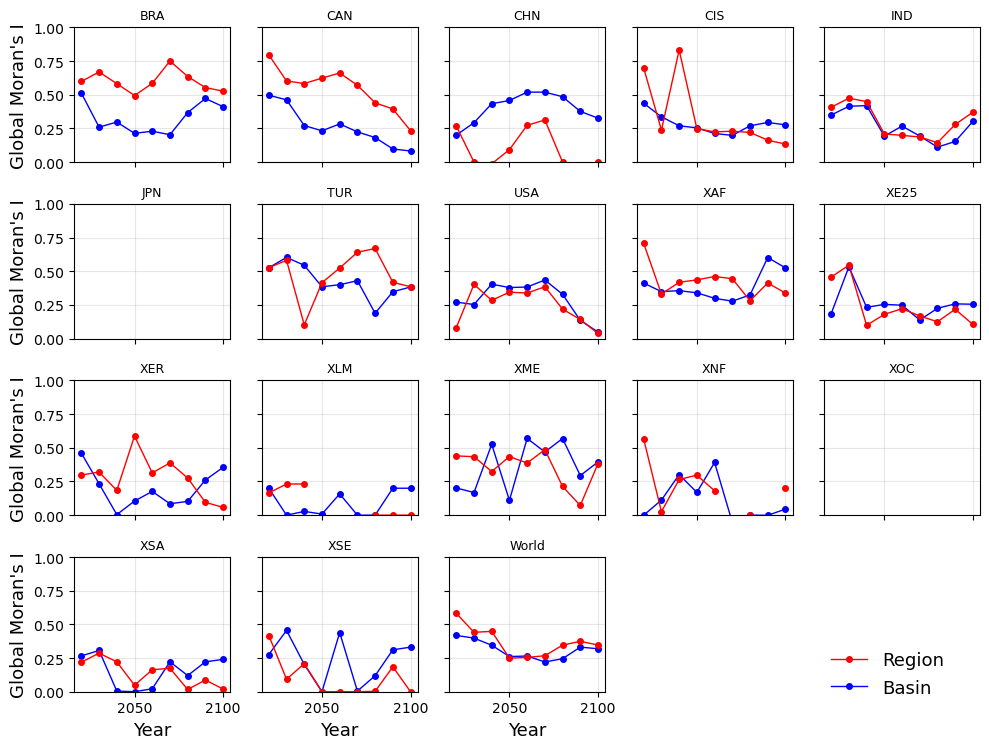

In [4]:
n = len(regions_all)
ncols = 5
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(10, 8),
    sharex=True,
    sharey=True
)

axes = axes.flatten()
for i, reg in enumerate(regions_all):
    ax = axes[i]

    # ---------- 17 regions ----------
    if reg != "World":
        d = df_regional[df_regional["region"] == reg]

        for mode, color in [("basin", "blue"), ("region", "red")]:
            dm = d[d["mode"] == mode]
            ax.plot(
                dm["year"], dm["moran_I"],
                color=color, marker="o", label=mode.capitalize(),markersize=4,linewidth=1
            )

        ax.set_title(reg, fontsize=9)

    # ---------- World ----------
    else:
        for mode, color in [("basin", "blue"), ("region", "red")]:
            dm = df_global[df_global["mode"] == mode]
            ax.plot(
                dm["year"], dm["moran_I"],
                color=color, marker="o", label=mode.capitalize(),markersize=4,linewidth=1
            )

        ax.set_title("World", fontsize=9)

    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)

    row = i // ncols
    col = i % ncols

    if col == 0:
        ax.set_ylabel("Global Moran's I", fontsize=13)
        ax.tick_params(axis="y", labelleft=True)
    else:
        ax.tick_params(axis="y", labelleft=False)

    if row == nrows - 1:
        ax.set_xlabel("Year", fontsize=13)
        ax.tick_params(axis="x", labelbottom=True)
    else:
        ax.tick_params(axis="x", labelbottom=False)

handles, labels = axes[0].get_legend_handles_labels()
order = [labels.index("Region"), labels.index("Basin")]

handles = [handles[i] for i in order]
labels  = [labels[i]  for i in order]

fig.legend(
    handles, labels,
    loc="center left",
    bbox_to_anchor=(0.82, 0.15),
    ncol=1,
    fontsize=13,
    frameon=False
)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig(
    f"../../plot/moran/17regions_plus_world_interannual_diff_moran_consistent.png",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

